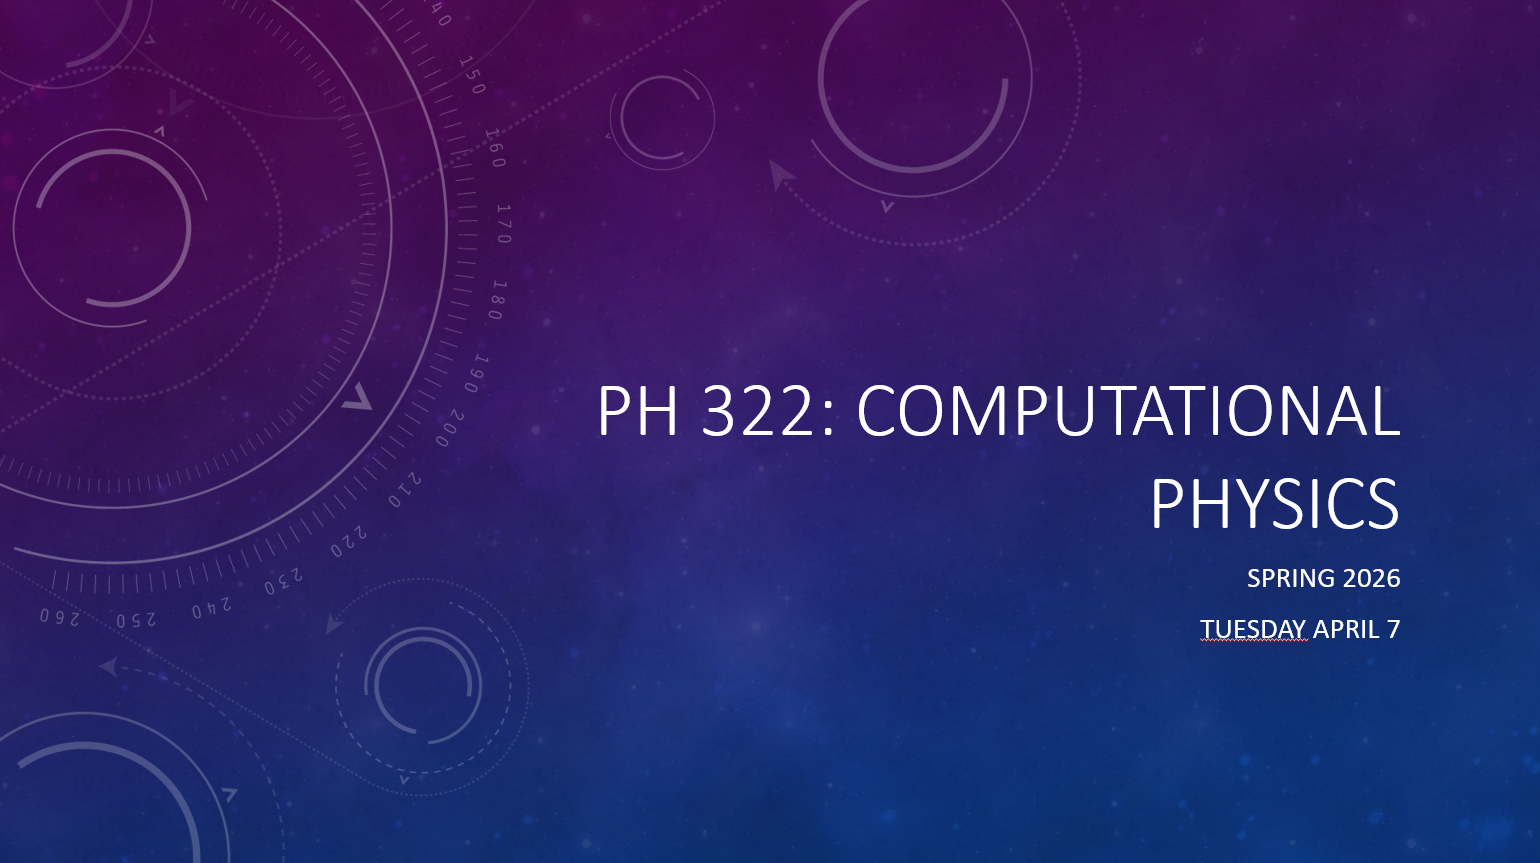

In [1]:
from IPython.display import Image, display
display(Image("header_lecture3.png"))

* Questions?
* HW 1 due tonight at 11:59pm 

Last class
* ```input()```
* Commenting
* Importing packages
* ```if``` statements
* ```while``` loops
* ```for``` loops
* lists
* tuples
* dictionaries

Today
* NumPy arrays
* User-defined functions
* Reading files

**Note:** You will need the ```numpy``` and ```matplotlib``` packages for today's class. If you don't have them already installed, you can load them "on the fly" by running this cell:

In [ ]:
%pip install numpy, matplotlib

In [16]:
from IPython.display import display, Math

# This will display a beautifully typeset equation
display(Math(r"e^{i\pi} + 1 = 0"))

<IPython.core.display.Math object>

In [ ]:
%pip install sympy

In [20]:
import sympy as sp
x = sp.Symbol('x')
expr = x**2 + sp.sqrt(x)

# Convert to LaTeX string
latex_code = sp.latex(expr)
print(latex_code) # Output: x^{2} + \sqrt{x}

\sqrt{x} + x^{2}


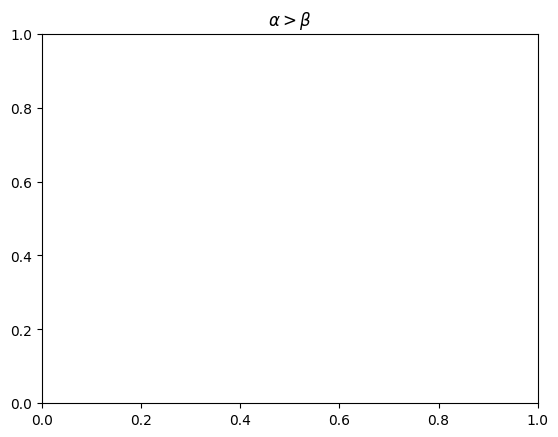

In [21]:
import matplotlib.pyplot as plt

plt.title(r"$\alpha > \beta$") # Renders as math
plt.show()

In [22]:
# Use 'r' for raw string to keep backslashes literal
latex_string = r"\frac{a}{b} = c"
print(latex_string) 
# Output: \frac{a}{b} = c

\frac{a}{b} = c


In [23]:
val = 10
# Double braces {{ }} are for LaTeX; single braces { } are for Python variables
print(rf"\text{{Value is }} {val}")
# Output: \text{Value is } 10

\text{Value is } 10


## Review practice exercise from last class

Calculate the motion of a mass on a spring undergoing simple harmonic motion (ignoring damping and friction). 

The position of a mass on a spring as a function of time is given by:

$$
x(t) = A \cos(\omega t)  
$$
 
Where:

* $A$ is the amplitude  
* $\omega$ is the angular frequency: $\omega=\sqrt{k/m}$
* $k$ is the spring constant
* *m* is the mass

Set:

* $A=1.0$ m
* $k=4.0$ N/m
* $m=1.0$ kg
  

**Instructions**

* Calculate the motion from 0 to 10 seconds in 0.1-second steps using either a ```while``` or ```for``` loop.  
* Store the times and positions in two separate lists. 
* Output the times and positions using a f-string.
* BONUS: Plot the motion vs. time using the ```plot``` function from package ```matplotlib.pyplot```. The syntax of ```plot``` is:

```
plot(xvalues, yvalues)
plot.show()
```


Time (s)   Position (m)
0.0  1.0
0.1  1.0
0.2  0.9
0.3  0.8
0.4  0.7
0.5  0.5
0.6  0.4
0.7  0.2
0.8  -0.0
0.9  -0.2


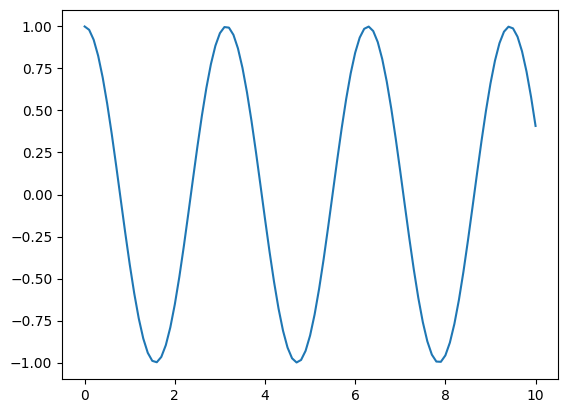

In [1]:
# Possible solution using a for loop
import matplotlib.pyplot as plt
import math

# define constants
A = 1.0 # amplitude in meters
k = 4.0 # spring constant in N/m
m = 1.0 # mass in kg

# calculate the angular frequency  
omega = math.sqrt(k/m)

# create empty lists to store times and positions
times = []
positions = []

for i in range(101):
    t = 0.1*i
    x = A * math.cos(omega * t)
    times.append(t)
    positions.append(x)
   
# print the first 10 time-position pairs
print("Time (s)   Position (m)")
for i in range(10):
    print(f"{times[i]:.1f}  {positions[i]:.1f}")

# plot the motion
plt.plot(times, positions)
plt.show()

Time (s)   Position (m)
0.0  1.0
0.1  1.0
0.2  0.9
0.3  0.8
0.4  0.7
0.5  0.5
0.6  0.4
0.7  0.2
0.8  -0.0
0.9  -0.2


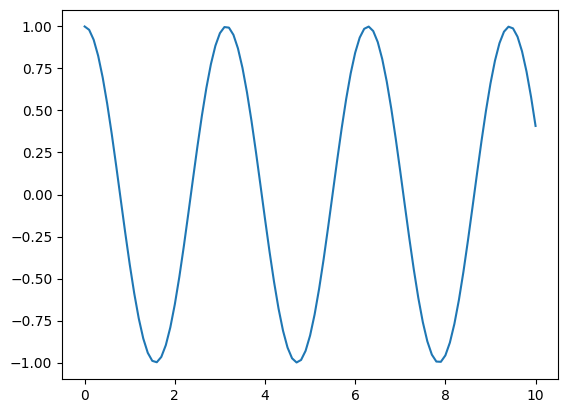

In [2]:
# Possible solution using a while loop
import matplotlib.pyplot as plt
import math

# define constants
A = 1.0 # amplitude in meters
k = 4.0 # spring constant in N/m
m = 1.0 # mass in kg

# calculate the angular frequency  
omega = math.sqrt(k/m)

# create empty lists to store times and positions
times = []
positions = []

# initialize t
t = 0

while t <= 10: 
    x = A * math.cos(omega * t)
    times.append(t)
    positions.append(x)
    t = t + 0.1   
    

# print the first 10 time-position pairs
print("Time (s)   Position (m)")
for i in range(10):
    print(f"{times[i]:.1f}  {positions[i]:.1f}")

# plot the motion
plt.plot(times, positions)
plt.show()

## NumPy Arrays

Last class we learned that lists are good for storing a sequence of objects like floats, but they are not very good for use in mathematical operations. For example, if we create a list of floats and try to scale each of them by 3 in an intuitive way, we get this result instead:

In [3]:
m = [1.0, 2.0, 3.0, 4.0]
print(2*m)

[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]


We also want a data structure we can use to store matrices and other *N*-dimensional data sets. 

Array objects are not in the base Python distribution. We have to import them from the **NumPy** (Numerical Python) package.
In fact, many of our programs this term will require us to import array and other functions from *numpy*.

* Like lists, arrays allow us to store and manipulate ordered sets of data or numbers. 
* Unlike lists, we are able to perform mathematical operations on all elements in an array, but we will need new functions to do this.
* Unlike lists, an array will contain elements of only one data type, e.g., either all integers or all floats, not a mixture.
* Unlike lists, once you declare the size of an array, i.e., the number of elements it contains, you can't change it.
* An array can be one-dimensional like a vector, two-dimensional like a matrix, or N-dimensional, where each dimension can be a different size. 
* The *shape* of an array is determined by the number of its dimensions and the size of each dimension, e.g., an MxN array is a two-dimensional array with M rows and N columns. A 2x4 array has 2 rows and 4 columns. 


It is conventional to import *numpy as *np* like this:

In [4]:
import numpy as np

We then attach the *np* prefix onto all function names from *numpy*.



### ```np.array()```

Let's first use the *numpy* function ```array()``` to convert a Python list to a *numpy* array.

To do this, we first create a Python list, then use the name of the list as an argument to the ```array()``` function. 

In [5]:
import numpy as np

# create a list
m_list = [1.0, 2.0, 3.0, 4.0]

#convert list to a numpy array
m_array = np.array(m_list)

# print out the new array
print(m_array)

[1. 2. 3. 4.]


Using the ```type()``` function, we see this creates a new object type called *numpy.ndarray*:

In [6]:
type(m_array)

numpy.ndarray

Let's now try to do some math using the new array. We will first multiple all values in the array by 3:

In [24]:
# scale all numbers in m_array by 3
print(3*m_array)

[ 3.  6.  9. 12.]


We see each element in the array has been multiplied by 3.

We can add arrays: 

In [25]:
print(m_array + m_array)

[2. 4. 6. 8.]


This adds the array element-wise.

We can pass the entire array to a function and the function will act on each element, but we must use functions from the *numpy* package, not the*math* package, because the *math* package only works on scalar variables:

In [11]:
# take the square root of each array member by using the numpy function sqrt()
print(np.sqrt(m_array))

[1.         1.41421356 1.73205081 2.        ]


Notice we will get an error if we try to use a *math* function on an array:

In [12]:
import math as m

# try to take the square root of an array using a math module function
print(m.sqrt(m_array))

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [26]:
import numpy as np
print(np.sqrt(m_array))

[1.         1.41421356 1.73205081 2.        ]


We can create a 2-dimensional array by enclosing two lists in square brackets:

In [13]:
M = np.array([ [1.0, 2.0], [3.0, 4.0] ])
print(M)

[[1. 2.]
 [3. 4.]]


And perform operations on the matrix:

In [27]:
# Take the transpose of the matrix
print(np.transpose(M))


[[1. 3.]
 [2. 4.]]


In [28]:
# Take the dot product of the matrix with itself
print(np.dot(M, M))

[[ 7. 10.]
 [15. 22.]]


There are too many *numpy* functions to review. But you can get a list of all the functions using ```dir```:

In [29]:
dir(np)

['False_',
 'ScalarType',
 'True_',
 '_CopyMode',
 '_NoValue',
 '__NUMPY_SETUP__',
 '__all__',
 '__array_api_version__',
 '__array_namespace_info__',
 '__builtins__',
 '__cached__',
 '__config__',
 '__dir__',
 '__doc__',
 '__expired_attributes__',
 '__file__',
 '__former_attrs__',
 '__future_scalars__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__numpy_submodules__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_array_api_info',
 '_core',
 '_distributor_init',
 '_expired_attrs_2_0',
 '_globals',
 '_int_extended_msg',
 '_mat',
 '_msg',
 '_pyinstaller_hooks_dir',
 '_pytesttester',
 '_specific_msg',
 '_type_info',
 '_typing',
 '_utils',
 'abs',
 'absolute',
 'acos',
 'acosh',
 'add',
 'all',
 'allclose',
 'amax',
 'amin',
 'angle',
 'any',
 'append',
 'apply_along_axis',
 'apply_over_axes',
 'arange',
 'arccos',
 'arccosh',
 'arcsin',
 'arcsinh',
 'arctan',
 'arctan2',
 'arctanh',
 'argmax',
 'argmin',
 'argpartition',
 'argsort',
 'argwhere',
 'around',
 'array',
 'arr

### Other ways to create arrays

There are different *numpy* functions we can use to create an array, depending on how we wish to initialize the array. 

Suppose we want to create a 4-row x 3-column float array, and don't care what the initial value of each element is in the array. In this case we can use the ```empty()``` function defined by:

```
np.empty(shape_of_array, data_type)
```

where the *shape of the array* is its dimensionality, e.g. 4x3; and *data_type* refers to the variable type, e.g., float, int, complex. You can specify the shape using either a list or a tuple.

In [32]:
# import the numpy module as np 
import numpy as np

# use the empty() function to create a 4x3 float array
a = np.empty((4,3), float)
type(a), a

(numpy.ndarray,
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]))

The intial values in the array will be just be whatever values happen to hanging around in the array's memory addresses.
If you know you will replace all the elements before using, it is fine to initially have random values in your array, but in other cases you might want more control over these initial values.

For example, if you wish to initialize your array with zeros, use the **zeros()** function:

```python
zeros(shape_of_array, data_type)
```

The arguments to **zeros()** are the same as **empty()**. 

In [31]:
a = np.zeros((4,3), float)
type(a), a

(numpy.ndarray,
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]))

In [50]:
a = np.zeros(10, float)
type(a), a

(numpy.ndarray, array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

We can create an array filled with a value of our choosing using the *np.full()* function:

```python
full(shape_of_array, fill_value)
```

In [33]:
a = np.full([4,3],3.14)
print(a)

[[3.14 3.14 3.14]
 [3.14 3.14 3.14]
 [3.14 3.14 3.14]
 [3.14 3.14 3.14]]


### ```np.arange()``` and ```np.linspace()```

Often we want to create a 1D array that contains evenly-spaced values over a specified range. For example, maybe we wish to create a vector of evenly-spaced times.

To create this we can use the numpy function ```arange()``` that has syntax:  

```python
np.arange(start_value, end_value, increment)
```

By default the increment is 1 and the start value is 0.

In [34]:
# create a range from 2 to 20, incremented by 2
b = np.arange(2,20,2)
print(type(b), b)

<class 'numpy.ndarray'> [ 2  4  6  8 10 12 14 16 18]


Note, like the ```range()``` function,  ```arange``` creates values up to but not including the end value.  

Unlike ```range()```, the parameters do not need to be integers :

In [39]:
# create a range from 1.1 to 9.1 incremented by 0.1
c = np.arange(1.1, 9.1+0.1, 0.1)
print (c)

[1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8
 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6
 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1 6.2 6.3 6.4
 6.5 6.6 6.7 6.8 6.9 7.  7.1 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8.  8.1 8.2
 8.3 8.4 8.5 8.6 8.7 8.8 8.9 9.  9.1]


There is another numpy function ```linspace()``` that is similar, but instead of specifying the increment, we specify the number of elements we want the vector to hold:

```python
np.linspace(start, end, number_of_elements)
```

Let's say we want to create a vector with 20 elements that span the range from 15 to 25:

In [37]:
# create an array of 20 numbers evenly spaced from 15 up to and including 25
d = np.linspace(15, 25, 20)
print(d)

[15.         15.52631579 16.05263158 16.57894737 17.10526316 17.63157895
 18.15789474 18.68421053 19.21052632 19.73684211 20.26315789 20.78947368
 21.31578947 21.84210526 22.36842105 22.89473684 23.42105263 23.94736842
 24.47368421 25.        ]


And just to confuse things, we see that the end value *is* included in the array elements, unlike the use of ```arange```.

## Accessing array elements

Accessing an array element is similar to accessing an element in a list:

In [40]:
# create a 1D array
B = np.array([10,11,12,13,14])

# print out elements by indexing
print(B[0], B[1], B[2], B[3])

10 11 12 13


Again take note, the index of the first element is 0 and the index of the last element is N-1 or 4. 


To access elements in a 2D array, first index the row number, then the column:

In [41]:
#create a 2D array
C = np.array([[1,2,3], [11,12,13]])

print (C)
# print out the element in the second row (index=1), third column (index=2)
print(C[1,2])

[[ 1  2  3]
 [11 12 13]]
13


Likewise we can assign a value to an element in an array using similar syntax:

In [42]:
C[0,1]=25

C

array([[ 1, 25,  3],
       [11, 12, 13]])

We can access an entire row of the array by using only 1 index:

In [43]:
C[0]

array([ 1, 25,  3])

Or we can access a column of an array by using a colon in the rows place:

In [44]:
C[:,0]

array([ 1, 11])

The colon means to include all rows.

We can also change elements in an entire row or column this way:

In [45]:
C[:,1]= [100,101]
C

array([[  1, 100,   3],
       [ 11, 101,  13]])



## Slicing

The use of a colon when it is part of an index is called **slicing**. As the name suggests, we can access or change slices of arrays. 

Let's say we have a 10 element 1D array and we want to access the first 5 elements, we could do this:

In [51]:
# create an array of 10 numbers from 11 to 200
E = np.linspace(11,200, 10)
print(E)

[ 11.  32.  53.  74.  95. 116. 137. 158. 179. 200.]


In [52]:
#print out the first 5 numbers
print(E[:5])

[11. 32. 53. 74. 95.]


We see this outputs the first five elements of the array, indices 0, 1, 2, 3, 4.

Or if we want to access elements from index 5 onwards:

In [53]:
print(E[5:])

[116. 137. 158. 179. 200.]


Or elements from index 5 to 7:

In [54]:
print(E[5:8])

[116. 137. 158.]


Notice we access elements up to but not including the end index we specify. 

We can also use a negative index which counts down from the end of the array dimension:

In [55]:
print(E[-3:])

[158. 179. 200.]


Finally, let's look at some of the ndarray object *attributes* that may come in handy. An *attribute* is a property of a Python object. Each object has its own set of attributes. To find the value of the attribute attach the attribute name with a period after the array name. 

Here are some useful attributes of a numpy array object:

*shape* - the shape of the array  
*size* - total number of elements in array  
*dtype* - the data type of the array

In [57]:
a = np.zeros([3,4], float)
a.shape
a

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

This means *a* is a 3x4 array. 

In [58]:
a.size

12

The size of the the array is the total number of elements. 

In [59]:
a.dtype

dtype('float64')

## Practice Exercise 1

Rewrite our simple harmonic motion program using arrays instead of lists.

* Create a 1D array filled with times from 0 to 10 seconds at 0.1 second intervals.
* Create an empty 1D array to hold positions of the same size as your times array.
* Use a ```for``` loop to loop through each time, calculate the position, and store the position in your positions array.
* Make a plot of position vs. time using the ```plot()``` function from package ```matplotlib.pyplot```:
```
plot(xvalues, yvalues)
plot.show()
```

The position of a mass on a spring as a function of time is given by:

$$
x(t) = A \cos(\omega t)  
$$
 
Where:

* $A$ is the amplitude  
* $\omega$ is the angular frequency: $\omega=\sqrt{k/m}$
* $k$ is the spring constant
* *m* is the mass






In [48]:
# Practice Exercise Code 1
"""
Simple Harmonic Motion
Acamaro Cutcher Apr 7, 2025
Calculate simple harmonic motion using arrays instead of list.
Status: In progress
"""
import numpy as np

time_array = np.arange(0, 10.1, 0.1)



array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. ])

### User-defined functions

We have already encountered a number of built-in and external Python functions, functions like ```input()```, ```print()```, ```sqrt()```, ```cos()```, etc. There will be many cases where we will need to write our own function to perform some task, e.g. calculating the value of a mathematical function for which no pre-defined function exists.  

Functions can be used for any repetitive task for which we do not want to repeat code. Using functions, we can shorten the length of our program and make our code more readable.

**Creating a function** in Python is pretty easy. The basic template looks like this:

```python
def function_name(list_of_arguments_sent_to_function):
    indented_block_of_code
    indented_block_of_code
    indented_block_of_code
    indented_block_of_code
    return <something>
```

* The keyword **def** tells Python we are defining a function.
* *function_name* is the name of the function and follows the same rules as variable names. 
* *list_of_arguments* are the arguments we pass to the function. There can be one or more arguments, or no arguments at all.
* The **def** line ends with a colon and must be followed by an indented block of code.
* The block_of_code of course is what the function does. This could be calculating a number, reading in data, making a plot, etc.
* Finally, most functions return an object, for example a float variable or a list. You can return one or more objects, or no objects at all.
* We use a function by calling it just like any other function.
* We typically define functions at the beginning of our program.
* Python ignores the function until it's called somewhere else in the program. 


### Our first function

Let's write a simple function called *m2ft()*, which converts distance in meters into feet. 

In [ ]:
# define a function to convert meters to feet
# the function name is m2ft. It takes one argument x and returns the variable feet.

# import the number of meters per foot
from scipy.constants import foot

# define function m2ft()
# input x: distance in meters
# output: distance in feet, float
def m2ft(x):
    feet = x/foot # notice the calculation is done on the variable x in the function definition, not on the variable we pass to the function
    return feet # send the value of feet back to the main program

# Start of main program. Python does not execute function code until the function is called.

# prompt user for distance in meters.
distance_m = float(input("Enter distance in units of meters: "))

# This is the calling statement, where we call the function and pass the variable as an argument to the function.
distance_ft = m2ft(distance_m)

# the function m2ft returns the value of feet and we assign it to the variable distance_ft
print(f"{distance_m} meters = {distance_ft:0.2f} ft.")

This is about as simple of a function we can write. It's obvious what the function does. 

* We pass an argument *x* to the function. 
* Inside the function, x is divided by the number of meters per foot and the value of feet is returned. 
* We call the function by using the function name and including the argument we wish to pass, just like the other functions we have used.

Note: You need to define functions before you use them, so put function declarations at the beginning of your program.

### Practice Exercise 2

Write a function to calculate the range of a projectile launched at angle $\theta$ with initial velocity $v_o$. 

$$
x = \frac{2v_o^2}{g}\sin(\theta)\cos(\theta)
$$

Prompt the use for $v_o$ and $\theta$, then pass these to your function. Have your function return the range. 

In [ ]:
# Practice Exercise 2

One other note. The variables created inside functions are **local** to that function. They are not available outside the function unless we pass them with *return*. 

For example, inside my range function I convert theta to radians. If I print the value of theta outside the function, will it be the original value in degrees or the converted value in radians?

In [ ]:
# import math functions
from math import cos, sin, pi

from scipy.constants import g
 
# incomplete code



We see that if we print theta outside the function, it is still the original value. 

Also, if a function variable is not defined inside the function, the function will look for that variable outside the function. 
For example, if we define *g* inside the function above, the function will use that value. If we don't, it will use the global value of *g* we imported from scipy.

### Passing an array to a function

Typically, when you pass a variable to a function, a copy of that variable is passed, not the variable itself. 

However, if an array is passed as an argument, the memory address to the array is passed instead, meaning that changes the function makes to the array will also change the original array. 

Take this example. 

Here I create an array called A and pass it to my function. Inside the function I change the value of one of the array elements. What happens to the original array A?

In [ ]:
from numpy import array

def change(x):
    x[0]=5
    return x

# define my array
A = array([10, 2, 5, 4])

# print the value of A before I pass it to my function
print (f"A before function call = {A}")

# call my function and pass the array A
change(A)

# now print the array again after the function call. 
print (f"A after function call = {A}")

    

We see that the original array was changed.

If you don't want the contents of your array to change inside the function, pass a copy of the array to the function instead using the numpy function *np.copy()*:

In [ ]:
from numpy import array, copy

def change(x):
    x[0]=5
    return x

# define array
A = array([10, 2, 5, 4])

# print A before passing it to the function
print (f"A before function call = {A}")

# now pass a copy of A to the function, not A itself
change(np.copy(A))

# print A after the function call.
print (f"A after function call = {A}")


### Returning more than one object

A function can return more than one object. It will return the objects using a tuple. 

Let's try:

In [ ]:
# define a function that returns two objects
def f(x):
    a = 2*x
    b = 3*x
    return a, b

r = 1
a = f(r)
a, type(f(r))

The function returns both values a and b in a **tuple**. 

If we want to assign each result that is returned by the function,  we could do something like:

In [ ]:
m = f(r)[0]
n = f(r)[1]
print (m, n)

Since the function returns a tuple of size 2, index 0 references the first integer, and index 1 references the second integer.  
We could also use a single assignment statement like this:

In [ ]:
m ,n = f(r)
m, n

## Reading data in from a text file

It is often the case we will want to read data in from a file.

Let's say we have data stored in a text file organized into columns. For example, here is a sample of monthly sunspot data. The first column is the number of the month since January 1749, and the second column is the average daily number of sunspots. 

1	62.6  
2	70.0  
3	55.7  
4	85.0  
5	83.5  
6	94.8  
7	66.3  
8	75.9  
9	75.5  
10	158.6  
11	85.2  
12	73.3  
13	75.9  
14	89.2  
15	88.3   

There are a number of ways we can read the file. Perhaps the easiest method to read in simply formatted data such as this, is to use the ```numpy``` function ```loadtxt()```. Its syntax is 

```python
numpy.loadtxt(fname, dtype=<class 'float'>, comments='#', delimiter=None, converters=None, skiprows=0, usecols=None, unpack=False, ndmin=0, encoding='bytes', max_rows=None, *, quotechar=None, like=None)
```

The output of ```loadtext()``` is a ```numpy``` array. 

There are a number parameters we can specify that determines how the data are read in and stored in the array. The most important parameters are:

**fname: file, str**
File, filename, to read. 

**dtype: data-type, optional**
Data-type of the resulting array; default: float. 

**delimiter: str, optional**
The character used to separate the values. The default is whitespace.

**skiprows: int, optional**
Skip the first skiprows lines, including comments; default: 0.

**usecols: int or sequence, optional**
Which columns to read, with 0 being the first. For example, usecols = (1,4,5) will extract the 2nd, 5th and 6th columns. The default, None, results in all columns being read.

[More information about loadtxt()](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html)

The output of ```loadtxt``` is a ```numpy``` array with a shape that corresponds to the data structure in the file (assuming the formatting is maintained throughout the file).

Let's try it:

In [ ]:
# demonstrate the use of np.loadtxt()

# loadtxt() is found in numpy
import numpy as np

# either one of these will work to specify the path
# CHANGE THIS TO YOUR PATH 
file = "C:\\Users\\cbuten\\Downloads\\sunspots.txt"
#file = "C:/Users/cbuten/Downloads/sunspots.txt"

# read the data into an array 
data_array = np.loadtxt(file)
print(data_array)

A cpl things to note. Python will look in your current working directory for your file. So you need to either put the file in your current working directory or include the full path to the file, which I do here. 

You can find out what the current working directory is by entering the IPython/Jupyter magic character **%** followed by *pwd*.

In [46]:
%pwd

'/Users/acamaro/Documents/University/Physics/Computational-Physics/Class Notes'

Windows uses backslashes to format path names. However in Python strings, the backslash is an escape character that has special meaning. In order to tell Python not to treat the backslash as an escape character I use a double backslash in the path name. 

```python
path = "G:\\My Drive\\Classes\\Ph322\\Textbooks\\Newman\\Programs and Data\\Chapter3\\"
```

Alternatively, you can use forward slashes in the path string:
```python
path = "G:/My Drive/Classes/Ph322/Textbooks/Newman/Programs and Data/Chapter3/"
```


We can now examine the contents of *data_array*.  First let's examine its shape using the *shape* attribute of an *ndarray* object:

In [ ]:
# Check out the shape of data_array
data_array.shape

We see it is a 3143x2 array, meaning it has 3143 rows and 2 columns.

In [ ]:
data_array.dtype

All the elements, even the months which were integers, are floats. The default array type is float, but you can change this in *loadtxt()*.

Let's look at some of the data in the array using an array slice. What will this output? 

In [ ]:
print(data_array[:12,:])

:12 means to extract all the rows starting at 0 up to but not including index 12. And the single colon that follows, means to include all columns of data. 

We will extract the months and sunspot data into 1D arrays with more meaningful names:

In [ ]:
months = data_array[:,0]
sunspots = data_array[:,1]

To grab the months, I fetch all the rows (:) but just the first column (index=0). And grab the second column (index=1) to get the sunspot data. 

Double-check if the arrays contain what we think they do: 

In [ ]:
months

Yes, the months (although they have been converted to floats)

In [ ]:
sunspots

Once the data are in arrays, we can plot using matplotlib.

In [ ]:
plt.plot(months, sunspots)

### Practice Exercise 3

On Canvas in the Data and Python Files module, there is a file called "monthly_in_situ_co2_mlo.txt" that contains monthly carbon dioxide concentrations at Mauna Loa. The decimal dates are stored in the 4th column, and the CO2 concentrations in units of parts per million are stored in the 5th column.

* Download the file.
* Read the file in using ```loadtxt``` and extract the decimal dates and CO2 values.
* Make a plot of CO2 vs. date.